In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('./dataset/unsw'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

./dataset/unsw/UNSW_NB15_training-set.csv


In [ ]:
df_train = pd.read_csv('./dataset/unsw/UNSW_NB15_training-set.csv')
df_test_raw = pd.read_csv('./dataset/unsw/UNSW_NB15_testing-set.csv')
df = df_train.copy()
print(f'Training set: {df_train.shape}')
print(f'Test set    : {df_test_raw.shape}')

In [3]:
df.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Length of Fwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd Header Length', 'Bwd Header Length',
       'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length',
       'Max Packet Length', 'Packet Length Mean', 'Packet Length Std',
       'Packet Length Variance', 'FIN Flag Count', 'PSH Flag Count',
       'ACK Flag Count', 'Average Packet Size', 'Subflow Fwd Bytes',
       'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_p

In [4]:
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,...,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min,Attack Type
0,22,1266342,41,2664,456,0,64.975610,109.864573,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
1,22,1319353,41,2664,456,0,64.975610,109.864573,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
2,22,160,1,0,0,0,0.000000,0.000000,0,0,...,243,0,32,0.0,0,0,0.0,0,0,Normal Traffic
3,22,1303488,41,2728,456,0,66.536585,110.129945,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
4,35396,77,1,0,0,0,0.000000,0.000000,0,0,...,290,0,32,0.0,0,0,0.0,0,0,Normal Traffic


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, accuracy_score
)
from sklearn.feature_selection import VarianceThreshold
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    GRU, Dense, Dropout, BatchNormalization,
    Bidirectional, Input, Masking
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau,
    ModelCheckpoint, TensorBoard
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

# Set seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)



In [6]:
df.shape

(2520751, 53)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2520751 entries, 0 to 2520750
Data columns (total 53 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Length of Fwd Packets  int64  
 4   Fwd Packet Length Max        int64  
 5   Fwd Packet Length Min        int64  
 6   Fwd Packet Length Mean       float64
 7   Fwd Packet Length Std        float64
 8   Bwd Packet Length Max        int64  
 9   Bwd Packet Length Min        int64  
 10  Bwd Packet Length Mean       float64
 11  Bwd Packet Length Std        float64
 12  Flow Bytes/s                 float64
 13  Flow Packets/s               float64
 14  Flow IAT Mean                float64
 15  Flow IAT Std                 float64
 16  Flow IAT Max                 int64  
 17  Flow IAT Min                 int64  
 18  Fwd IAT Total                int64  
 19  

In [8]:
df.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,...,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min
count,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,...,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06,2.520751e+06
mean,8.690744e+03,1.659032e+07,1.025880e+01,6.065243e+02,2.311993e+02,1.920377e+01,6.350189e+01,7.732029e+01,9.749253e+02,4.316019e+01,...,7.265707e+03,2.228741e+03,5.997266e+00,-3.082291e+03,9.152230e+04,1.719410e+05,6.542438e+04,9.337159e+06,9.763454e+06,8.892545e+06
std,1.901294e+04,3.523140e+07,7.943824e+02,1.011595e+04,7.563122e+02,6.079887e+01,1.955512e+02,2.968824e+02,2.038152e+03,7.088017e+01,...,1.459805e+04,8.924482e+03,6.743909e+02,1.149769e+06,6.858746e+05,1.084664e+06,6.106447e+05,2.484810e+07,2.561725e+07,2.458139e+07
min,0.000000e+00,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,-1.000000e+00,-1.000000e+00,0.000000e+00,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.300000e+01,2.080000e+02,2.000000e+00,1.200000e+01,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,...,-1.000000e+00,-1.000000e+00,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,5.062000e+04,2.000000e+00,6.600000e+01,4.000000e+01,2.000000e+00,3.625000e+01,0.000000e+00,9.700000e+01,0.000000e+00,...,2.510000e+02,0.000000e+00,1.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.430000e+02,5.332968e+06,6.000000e+00,3.320000e+02,2.020000e+02,3.700000e+01,5.200000e+01,7.419280e+01,7.460000e+02,8.200000e+01,...,8.192000e+03,2.350000e+02,3.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553500e+04,1.200000e+08,2.197590e+05,1.290000e+07,2.482000e+04,2.325000e+03,5.940857e+03,7.125597e+03,1.953000e+04,2.896000e+03,...,6.553500e+04,6.553500e+04,2.135570e+05,1.380000e+02,1.100000e+08,1.100000e+08,1.100000e+08,1.200000e+08,1.200000e+08,1.200000e+08


In [ ]:
df['attack_cat'].value_counts()

In [10]:
numeric_df = df.select_dtypes(include=[np.number])
print('=== Data Quality ===')
print(f'Rows          : {len(df):,}')
print(f'Columns       : {len(df.columns)}')
print(f'NaN values    : {df.isnull().sum().sum():,}')
print(f'Inf values    : {np.isinf(numeric_df).sum().sum():,}')
print(f'Duplicates    : {df.duplicated().sum():,}')
print(f'Numeric cols  : {len(numeric_df.columns)}')
print(f'\nValue range   : [{numeric_df.min().min():.4f}, {numeric_df.max().max():.4f}]')


=== Data Quality ===
Rows          : 2,520,751
Columns       : 53
NaN values    : 0
Inf values    : 0
Duplicates    : 161
Numeric cols  : 52

Value range   : [-32212234632.0000, 2071000000.0000]


In [11]:
df.duplicated().sum()

np.int64(161)

In [ ]:
df_test_raw = df_test_raw.drop_duplicates()
df = df.drop_duplicates()

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.shape

(2520590, 53)

In [ ]:
LABEL_COL  = 'attack_cat'   # multi-class attack category column
BENIGN_STR = 'Normal'        # benign label value in UNSW-NB15

print(f'Using label column : {LABEL_COL}')
print(f'Benign label value : {BENIGN_STR}')
print(f'
Class distribution:')
print(df[LABEL_COL].value_counts().to_string())

In [16]:
# ── Quick data quality check ──────────────────────────────────────────────────
numeric_df = df.select_dtypes(include=[np.number])
print('=== Data Quality ===')
print(f'Rows          : {len(df):,}')
print(f'Columns       : {len(df.columns)}')
print(f'NaN values    : {df.isnull().sum().sum():,}')
print(f'Inf values    : {np.isinf(numeric_df).sum().sum():,}')
print(f'Duplicates    : {df.duplicated().sum():,}')
print(f'Numeric cols  : {len(numeric_df.columns)}')
print(f'\nValue range   : [{numeric_df.min().min():.4f}, {numeric_df.max().max():.4f}]')


=== Data Quality ===
Rows          : 2,520,590
Columns       : 53
NaN values    : 0
Inf values    : 0
Duplicates    : 0
Numeric cols  : 52

Value range   : [-32212234632.0000, 2071000000.0000]


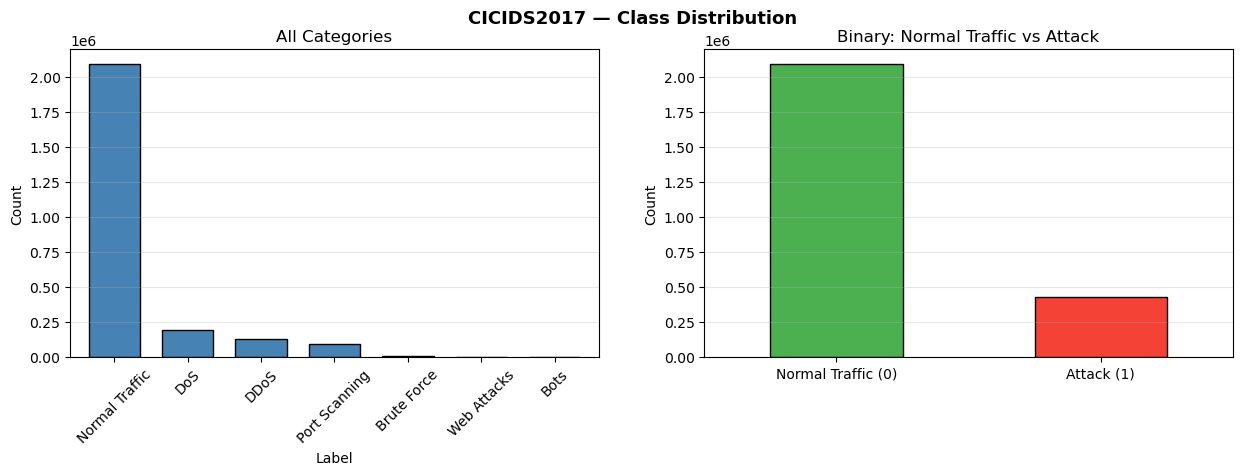

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
fig.suptitle('UNSW-NB15 — Class Distribution', fontsize=13, fontweight='bold')

# All attack types
counts = df[LABEL_COL].value_counts()
counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black', width=0.7)
axes[0].set_title('All Categories')
axes[0].set_xlabel('Label'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Binary
is_benign   = df[LABEL_COL].astype(str).str.strip() == BENIGN_STR
binary_cnts = pd.Series({'Normal Traffic (0)': is_benign.sum(), 'Attack (1)': (~is_benign).sum()})
binary_cnts.plot(kind='bar', ax=axes[1], color=['#4CAF50','#F44336'], edgecolor='black', width=0.5)
axes[1].set_title('Binary: Normal Traffic vs Attack')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', alpha=0.3)

In [18]:
# 3.1 — Binary label encoding
df['binary_label'] = df[LABEL_COL].apply(
    lambda x: 0 if str(x).strip() == BENIGN_STR else 1
)
y = df['binary_label'].values

print('Binary label distribution:')
print(f'  Normal Traffic (0) : {(y==0).sum():>10,}  ({(y==0).mean()*100:.1f}%)')
print(f'  Attack         (1) : {(y==1).sum():>10,}  ({(y==1).mean()*100:.1f}%)')
print(f'  Imbalance ratio    :  1 : {(y==1).sum()/max((y==0).sum(),1):.2f}')


Binary label distribution:
  Normal Traffic (0) :  2,094,896  (83.1%)
  Attack         (1) :    425,694  (16.9%)
  Imbalance ratio    :  1 : 0.20


In [ ]:
# 3.2 -- Build feature matrix
# Drop label columns + 'id' (row index) + 'label' (binary ground-truth numeric)
# Categorical cols (proto, service, state) are excluded by select_dtypes
DROP = [LABEL_COL, 'binary_label', 'id', 'label']
DROP = [c for c in DROP if c in df.columns]

X = df.drop(columns=DROP).select_dtypes(include=[np.number])
print(f'Feature matrix: {X.shape[0]:,} rows x {X.shape[1]} features')

In [20]:
df.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Length of Fwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd Header Length', 'Bwd Header Length',
       'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length',
       'Max Packet Length', 'Packet Length Mean', 'Packet Length Std',
       'Packet Length Variance', 'FIN Flag Count', 'PSH Flag Count',
       'ACK Flag Count', 'Average Packet Size', 'Subflow Fwd Bytes',
       'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_p

In [21]:
# 3.3 — Safety cleanup (handles any leftover inf/nan)
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))
print(f'After cleanup — NaN: {X.isnull().sum().sum()} | Inf: {np.isinf(X).sum().sum()}')


After cleanup — NaN: 0 | Inf: 0


In [22]:
# 3.4 — Remove near-zero variance features
vt = VarianceThreshold(threshold=1e-4)
X_vt = vt.fit_transform(X)
SELECTED_FEATURES = X.columns[vt.get_support()].tolist()
X = pd.DataFrame(X_vt, columns=SELECTED_FEATURES)
NUM_FEATURES = X.shape[1]
print(f'Features kept : {NUM_FEATURES}  (removed {len(vt.get_support()) - NUM_FEATURES} low-variance)')


Features kept : 52  (removed 0 low-variance)


In [ ]:
# 3.5 -- Use official UNSW-NB15 pre-defined split
# Training file  -> train / val (85 / 15, stratified)
# Testing file   -> held-out test set
# Scaler is fitted on train only -- no leakage

# --- Prepare official test set with same pipeline ---
df_test_raw['binary_label'] = df_test_raw[LABEL_COL].apply(
    lambda x: 0 if str(x).strip() == BENIGN_STR else 1
)
DROP_test = [LABEL_COL, 'binary_label', 'id', 'label']
DROP_test = [c for c in DROP_test if c in df_test_raw.columns]

X_test_raw = df_test_raw.drop(columns=DROP_test).select_dtypes(include=[np.number])
X_test_raw = X_test_raw.replace([np.inf, -np.inf], np.nan)
# Keep only VarianceThreshold-selected features; fill NaN with training medians
X_test_raw = X_test_raw[SELECTED_FEATURES].fillna(X.median())

y_test      = df_test_raw['binary_label'].values
y_type_test = df_test_raw[LABEL_COL].astype(str).values

# --- Split training set into train / val ---
X_arr      = X.values
y_type_arr = df[LABEL_COL].astype(str).values

X_train, X_val, y_train, y_val, y_type_train, y_type_val = train_test_split(
    X_arr, y, y_type_arr, test_size=0.15, random_state=SEED, stratify=y
)
X_test = X_test_raw.values

print(f'Train : {X_train.shape}   Normal:{(y_train==0).sum():,}  Attack:{(y_train==1).sum():,}')
print(f'Val   : {X_val.shape}     Normal:{(y_val==0).sum():,}    Attack:{(y_val==1).sum():,}')
print(f'Test  : {X_test.shape}    Normal:{(y_test==0).sum():,}   Attack:{(y_test==1).sum():,}')

In [24]:
# 3.6 — StandardScaler: fit on TRAIN only, transform all three
# ✅ Prevents data leakage — val/test statistics never influence the scaler
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)   # learns mean & std from train only
X_val   = scaler.transform(X_val)         # applies train's mean & std
X_test  = scaler.transform(X_test)        # applies train's mean & std
print(f'Scaled — Train mean≈{X_train.mean():.4f} | std≈{X_train.std():.4f}')



Scaled — Train mean≈0.0000 | std≈1.0000


In [25]:
df.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,...,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min,binary_label
count,2.520590e+06,2.520590e+06,2.520590e+06,2.520590e+06,2.520590e+06,2.520590e+06,2.520590e+06,2.520590e+06,2.520590e+06,2.520590e+06,...,2.520590e+06,2.520590e+06,2.520590e+06,2.520590e+06,2.520590e+06,2.520590e+06,2.520590e+06,2.520590e+06,2.520590e+06,2.520590e+06
mean,8.689420e+03,1.659138e+07,1.025937e+01,6.065630e+02,2.312140e+02,1.920495e+01,6.350589e+01,7.732523e+01,9.749875e+02,4.316292e+01,...,2.227698e+03,5.997646e+00,-3.082490e+03,9.152814e+04,1.719520e+05,6.542856e+04,9.337756e+06,9.764078e+06,8.893113e+06,1.688866e-01
std,1.901153e+04,3.523228e+07,7.944078e+02,1.011627e+04,7.563342e+02,6.080063e+01,1.955568e+02,2.968912e+02,2.038203e+03,7.088161e+01,...,8.922472e+03,6.744124e+02,1.149806e+06,6.858961e+05,1.084698e+06,6.106639e+05,2.484878e+07,2.561795e+07,2.458208e+07,3.746518e-01
min,0.000000e+00,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,-1.000000e+00,0.000000e+00,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.300000e+01,2.080000e+02,2.000000e+00,1.200000e+01,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,...,-1.000000e+00,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,5.062500e+04,2.000000e+00,6.600000e+01,4.000000e+01,2.000000e+00,3.625000e+01,0.000000e+00,9.800000e+01,0.000000e+00,...,0.000000e+00,1.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.430000e+02,5.333478e+06,6.000000e+00,3.320000e+02,2.020000e+02,3.700000e+01,5.200000e+01,7.419280e+01,7.460000e+02,8.200000e+01,...,2.350000e+02,3.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553500e+04,1.200000e+08,2.197590e+05,1.290000e+07,2.482000e+04,2.325000e+03,5.940857e+03,7.125597e+03,1.953000e+04,2.896000e+03,...,6.553500e+04,2.135570e+05,1.380000e+02,1.100000e+08,1.100000e+08,1.100000e+08,1.200000e+08,1.200000e+08,1.200000e+08,1.000000e+00


In [26]:
print('Applying SMOTE to training set only...')
smote = SMOTE(random_state=SEED, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
print(f'Before SMOTE: Normal={( y_train==0).sum():,}  Attack={(y_train==1).sum():,}')
print(f'After  SMOTE: Normal={(y_train_bal==0).sum():,}  Attack={(y_train_bal==1).sum():,}')

Applying SMOTE to training set only...
Before SMOTE: Normal=1,467,264  Attack=298,156
After  SMOTE: Normal=1,467,264  Attack=1,467,264


In [27]:
TIMESTEPS = 1

# Build a feature graph (adjacency) from balanced-train feature correlations
corr = np.corrcoef(X_train_bal, rowvar=False)
corr = np.nan_to_num(np.abs(corr), nan=0.0, posinf=0.0, neginf=0.0)
np.fill_diagonal(corr, 1.0)

# Keep top-k neighbors per feature to reduce noisy/weak edges
TOP_K = 8
idx = np.argsort(corr, axis=1)[:, -TOP_K:]
mask = np.zeros_like(corr)
rows = np.arange(corr.shape[0])[:, None]
mask[rows, idx] = 1.0
A = corr * mask
A = np.maximum(A, A.T)
np.fill_diagonal(A, 1.0)

# Symmetric normalization: A_hat = D^{-1/2} A D^{-1/2}
deg = A.sum(axis=1)
deg_inv_sqrt = np.power(deg + 1e-8, -0.5)
A_norm = (deg_inv_sqrt[:, None] * A) * deg_inv_sqrt[None, :]

X_train_lstm = X_train_bal.reshape(-1, TIMESTEPS, NUM_FEATURES)
X_val_lstm = X_val.reshape(-1, TIMESTEPS, NUM_FEATURES)
X_test_lstm = X_test.reshape(-1, TIMESTEPS, NUM_FEATURES)

print('GCN + BiGRU input shapes:')
print(f'  Train : {X_train_lstm.shape}')
print(f'  Val   : {X_val_lstm.shape}')
print(f'  Test  : {X_test_lstm.shape}')
print(f'  Features per timestep: {NUM_FEATURES}')
print(f'  Graph edges retained: {(A > 0).sum():,}')

GCN + BiGRU input shapes:
  Train : (2934528, 1, 52)
  Val   : (377081, 1, 52)
  Test  : (378089, 1, 52)
  Features per timestep: 52
  Graph edges retained: 566


In [28]:
class SimpleGCN(tf.keras.layers.Layer):
    def __init__(self, units, adjacency, activation='relu', l2_reg=1e-3, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.adjacency = tf.constant(adjacency, dtype=tf.float32)
        self.activation = tf.keras.activations.get(activation)
        self.l2_reg = l2_reg

    def build(self, input_shape):
        in_dim = int(input_shape[-1])
        self.kernel = self.add_weight(
            name='kernel',
            shape=(in_dim, self.units),
            initializer='glorot_uniform',
            regularizer=l2(self.l2_reg),
            trainable=True,
        )
        self.bias = self.add_weight(
            name='bias',
            shape=(self.units,),
            initializer='zeros',
            trainable=True,
        )

    def call(self, inputs):
        # inputs: (batch, timesteps=1, features)
        x = tf.squeeze(inputs, axis=1)
        x = tf.matmul(x, self.adjacency)
        x = tf.matmul(x, self.kernel) + self.bias
        if self.activation is not None:
            x = self.activation(x)
        return tf.expand_dims(x, axis=1)


def build_gcn_bigru(num_features, adjacency, timesteps=1, dropout=0.3, reg=1e-3):
    model = Sequential(name='GCN_BiGRU_AnomalyIDS')
    model.add(Input(shape=(timesteps, num_features)))

    # GCN front-end before recurrent blocks
    model.add(SimpleGCN(num_features, adjacency=adjacency, activation='relu', l2_reg=reg, name='gcn_front'))

    # Block 1
    model.add(Bidirectional(GRU(128, return_sequences=True,
                                kernel_regularizer=l2(reg),
                                recurrent_regularizer=l2(reg))))
    model.add(BatchNormalization())
    model.add(Dropout(dropout))

    # Block 2
    model.add(Bidirectional(GRU(64, return_sequences=False,
                                kernel_regularizer=l2(reg))))
    model.add(BatchNormalization())
    model.add(Dropout(dropout))

    # Dense head
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(reg)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout / 2))

    model.add(Dense(32, activation='relu'))
    model.add(Dropout(dropout / 2))

    # Output
    model.add(Dense(1, activation='sigmoid', name='anomaly_output'))
    return model


model = build_gcn_bigru(NUM_FEATURES, A_norm, TIMESTEPS)
model.summary()

Model: "GCN_BiGRU_AnomalyIDS"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gcn_front (SimpleGCN)           │ (None, 1, 52)          │         2,756 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 1, 256)         │       139,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       123,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ anomaly_output (Dense)          │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 278,341 (1.06 MB)

 Trainable params: 277,445 (1.06 MB)

 Non-trainable params: 896 (3.50 KB)

In [29]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)
print('✅ Model compiled!')

✅ Model compiled!


In [30]:
# Class weights — extra guard against any residual imbalance
cw = compute_class_weight('balanced', classes=np.unique(y_train_bal), y=y_train_bal)
CLASS_WEIGHTS = dict(enumerate(cw))
print(f'Class weights: {CLASS_WEIGHTS}')


Class weights: {0: np.float64(1.0), 1: np.float64(1.0)}


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# PHASE 1 — Initial Training  (LR = 1e-3)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print('🚀 PHASE 1 — Initial Training')
print('='*50)

cb1 = [
    EarlyStopping(monitor='val_auc', patience=10,
                  restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5,
                      min_lr=1e-6, verbose=1),
    ModelCheckpoint('./dataset/unsw/best_phase1.weights.h5',
                    monitor='val_auc', save_best_only=True, mode='max',
                    save_weights_only=True, verbose=1)
]

h1 = model.fit(
    X_train_lstm, y_train_bal,
    validation_data=(X_val_lstm, y_val),
    epochs=50,
    batch_size=512,
    class_weight=CLASS_WEIGHTS,
    callbacks=cb1,
    verbose=1
)
print('\n✅ Phase 1 complete!')

🚀 PHASE 1 — Initial Training
Epoch 1/50
5728/5732 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9680 - auc: 0.9959 - loss: 0.0968 - precision: 0.9559 - recall: 0.9812
Epoch 1: val_auc improved from None to 0.99729, saving model to ./dataset/unsw/best_phase1.weights.h5
5732/5732 ━━━━━━━━━━━━━━━━━━━━ 77s 13ms/step - accuracy: 0.9685 - auc: 0.9961 - loss: 0.0941 - precision: 0.9566 - recall: 0.9815 - val_accuracy: 0.9664 - val_auc: 0.9973 - val_loss: 0.0824 - val_precision: 0.8437 - val_recall: 0.9830 - learning_rate: 0.0010
Epoch 2/50
5729/5732 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9706 - auc: 0.9965 - loss: 0.0876 - precision: 0.9589 - recall: 0.9833
Epoch 2: val_auc did not improve from 0.99729
5732/5732 ━━━━━━━━━━━━━━━━━━━━ 80s 14ms/step - accuracy: 0.9708 - auc: 0.9965 - loss: 0.0870 - precision: 0.9592 - recall: 0.9834 - val_accuracy: 0.9728 - val_auc: 0.9972 - val_loss: 0.0709 - val_precision: 0.8875 - val_recall: 0.9604 - learning_rate: 0.0010
Epoch 3/50
5730/5732 ━━━━

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# PHASE 2 — Fine-Tuning  (LR = 1e-4)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print('🔧 PHASE 2 — Fine-Tuning')
print('='*50)

# Rebuild architecture and load best phase-1 weights
model = build_gcn_bigru(NUM_FEATURES, A_norm, TIMESTEPS)
model.load_weights('./dataset/unsw/best_phase1.weights.h5')
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

cb2 = [
    EarlyStopping(monitor='val_auc', patience=8,
                  restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=4,
                      min_lr=1e-7, verbose=1),
    ModelCheckpoint('./dataset/unsw/best_finetuned.weights.h5',
                    monitor='val_auc', save_best_only=True, mode='max',
                    save_weights_only=True, verbose=1)
]

h2 = model.fit(
    X_train_lstm, y_train_bal,
    validation_data=(X_val_lstm, y_val),
    epochs=30,
    batch_size=256,
    class_weight=CLASS_WEIGHTS,
    callbacks=cb2,
    verbose=1
)
print('\n✅ Phase 2 complete!')

In [ ]:
# Load best fine-tuned weights and predict on the held-out test set
best_model = build_gcn_bigru(NUM_FEATURES, A_norm, TIMESTEPS)
best_model.load_weights('./dataset/unsw/best_finetuned.weights.h5')

y_prob = best_model.predict(X_test_lstm, batch_size=512, verbose=0).flatten()

# Optimal threshold via Youden's J  (maximises TPR - FPR)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
opt_idx = np.argmax(tpr - fpr)
OPT_THRESHOLD = float(thresholds[opt_idx])
y_pred = (y_prob >= OPT_THRESHOLD).astype(int)

print(f'Optimal threshold (Youden J): {OPT_THRESHOLD:.4f}')

In [ ]:
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
f1 = f1_score(y_test, y_pred)

print('=' * 50)
print('   GCN + BiGRU ANOMALY IDS  —  TEST RESULTS')
print('=' * 50)
print(f'  Accuracy  :  {acc * 100:.2f}%')
print(f'  AUC-ROC   :  {auc * 100:.2f}%')
print(f'  F1-Score  :  {f1 * 100:.2f}%')
print()
print(classification_report(y_test, y_pred, target_names=['Normal Traffic', 'Attack']))

In [ ]:
# Save current accuracy for baseline
baseline_acc = acc
print(f"Baseline Test Accuracy: {baseline_acc:.4f}")

# Optional: Hyperparameter Tuning
run_tuning = True  # Set to False to skip tuning
if run_tuning:
    import keras_tuner as kt
    def build_tuned_model(hp):
        reg = hp.Choice('l2_reg', [1e-2, 1e-3, 1e-4])
        dropout = hp.Float('dropout', 0.2, 0.5, step=0.1)
        gru1_units = hp.Choice('gru1_units', [64, 128, 256])
        gru2_units = hp.Choice('gru2_units', [32, 64, 128])
        lr = hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])
        model = Sequential(name='GCN_BiGRU_AnomalyIDS_Tuned')
        model.add(Input(shape=(TIMESTEPS, NUM_FEATURES)))
        model.add(SimpleGCN(NUM_FEATURES, adjacency=A_norm, activation='relu', l2_reg=reg, name='gcn_front'))
        model.add(Bidirectional(GRU(gru1_units, return_sequences=True, kernel_regularizer=l2(reg), recurrent_regularizer=l2(reg))))
        model.add(BatchNormalization())
        model.add(Dropout(dropout))
        model.add(Bidirectional(GRU(gru2_units, return_sequences=False, kernel_regularizer=l2(reg))))
        model.add(BatchNormalization())
        model.add(Dropout(dropout))
        model.add(Dense(64, activation='relu', kernel_regularizer=l2(reg)))
        model.add(BatchNormalization())
        model.add(Dropout(dropout / 2))
        model.add(Dense(32, activation='relu'))
        model.add(Dropout(dropout / 2))
        model.add(Dense(1, activation='sigmoid', name='anomaly_output'))
        model.compile(
            optimizer=Adam(learning_rate=lr),
            loss='binary_crossentropy',
            metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
        )
        return model
    cb = [EarlyStopping(monitor='val_auc', patience=5, restore_best_weights=True, mode='max', verbose=1)]
    tuner = kt.RandomSearch(
        build_tuned_model,
        objective=kt.Objective('val_auc', direction='max'),
        max_trials=5,
        executions_per_trial=1,
        directory='kt_tuning',
        project_name='anomly_ids_gcn_bigru'
    )
    tuner.search(
        X_train_lstm, y_train_bal,
        validation_data=(X_val_lstm, y_val),
        epochs=20,
        batch_size=256,
        class_weight=CLASS_WEIGHTS,
        callbacks=cb,
        verbose=2
    )
    best_hp = tuner.get_best_hyperparameters(1)[0]
    best_model = tuner.get_best_models(1)[0]
    val_loss, val_acc, val_auc = best_model.evaluate(X_val_lstm, y_val, verbose=0)
    print(f'Best Hyperparameters: {best_hp.values}')
    print(f'Validation Accuracy: {val_acc:.4f}, AUC: {val_auc:.4f}')
    # Evaluate on test set
    y_prob_tuned = best_model.predict(X_test_lstm, batch_size=512, verbose=0).flatten()
    y_pred_tuned = (y_prob_tuned >= OPT_THRESHOLD).astype(int)
    acc_tuned = accuracy_score(y_test, y_pred_tuned)
    print(f"Tuned Test Accuracy: {acc_tuned:.4f}")
    print("Improvement: {:.4f}".format(acc_tuned - baseline_acc))
else:
    print("Hyperparameter tuning skipped.")


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('GCN + BiGRU Anomaly IDS — Test Evaluation', fontsize=13, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1)[:, None] * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=['Normal Traffic', 'Attack'],
            yticklabels=['Normal Traffic', 'Attack'],
            ax=axes[0], linewidths=0.5, annot_kws={'size': 13})
axes[0].set_title('Confusion Matrix (%)', fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

for i in range(2):
    for j in range(2):
        axes[0].text(j + 0.5, i + 0.72, f'n={cm[i, j]:,}',
                     ha='center', va='center', fontsize=9, color='dimgray')

# ROC Curve
axes[1].plot(fpr, tpr, color='#1565C0', lw=2.5, label=f'GCN+BiGRU  AUC={auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'gray', lw=1, ls='--', label='Random baseline')
axes[1].scatter(fpr[opt_idx], tpr[opt_idx], s=120, color='red', zorder=5,
                label=f'Best threshold = {OPT_THRESHOLD:.3f}')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('./evaluation.png', dpi=150)
plt.show()

In [ ]:
# Attack-wise confusion matrix (detected vs missed)
attack_mask = y_type_test != BENIGN_STR
attack_true = y_type_test[attack_mask]
attack_pred_detected = np.where(y_pred[attack_mask] == 1, 'Detected Attack', 'Missed (Pred Normal)')

attack_cm = pd.crosstab(
    pd.Series(attack_true, name='Attack Type'),
    pd.Series(attack_pred_detected, name='Prediction')
)
for col in ['Detected Attack', 'Missed (Pred Normal)']:
    if col not in attack_cm.columns:
        attack_cm[col] = 0
attack_cm = attack_cm[['Detected Attack', 'Missed (Pred Normal)']]
attack_cm_pct = attack_cm.div(attack_cm.sum(axis=1), axis=0).fillna(0.0) * 100

plt.figure(figsize=(10, 5))
ax = sns.heatmap(attack_cm_pct, annot=True, fmt='.1f', cmap='YlGnBu',
                 linewidths=0.5, cbar_kws={'label': 'Percent within attack type'})
ax.set_title('Attack-Type Confusion Matrix (%)', fontweight='bold')
ax.set_xlabel('Prediction')
ax.set_ylabel('True Attack Type')

for i, attack_name in enumerate(attack_cm.index):
    for j, col in enumerate(attack_cm.columns):
        ax.text(j + 0.5, i + 0.75, f"n={int(attack_cm.loc[attack_name, col]):,}",
                ha='center', va='center', fontsize=8, color='dimgray')

plt.tight_layout()
plt.show()

print('\nAttack detection recall by type (%):')
attack_recall = (attack_cm['Detected Attack'] / attack_cm.sum(axis=1) * 100).sort_values(ascending=False)
print(attack_recall.round(2).to_string())